Project Phase 1: Data Preparation and Analysis
Group Members:

1. MUHAMMAD ADAM BIN RAZALI             
2. MUHAMMAD NAIM BIN ABDULLAH           
3. MUHAMMAD AFIQ DANISH BIN MOHD HAZNI  

Matric Number:

1. A23CS0116
2. A23CS0134
3. A23CS0118

In [95]:
import pandas as pd

cars_reg = pd.read_csv('cars_2025.csv')
fuel_consumption = pd.read_csv('fuelConsumption.csv')

In [96]:
## Data Cleaning, Preparation and Wrangling

# Normalize the attributes of "fuel_consumption" and "cars_reg" for model and maker
cars_reg['model_normalize'] = cars_reg['model'].str.lower().str.strip()
cars_reg['maker_normalize'] = cars_reg['maker'].str.lower().str.strip()
fuel_consumption['MODEL_normalize'] = fuel_consumption['MODEL'].str.lower().str.strip()
fuel_consumption['MAKE_normalize'] = fuel_consumption['MAKE'].str.lower().str.strip()

In [97]:
# Normalize the 'FUEL' and 'FUELTYPE' columns in fuel_consumption and cars_reg using mapping method
hybrid_fuel_mapping = {
    'X': 'hybrid_petrol',
    'Z': 'hybrid_petrol',
    'D': 'diesel',
    'E': 'electric'
}

normal_fuel_mapping = {
    'X': 'petrol',
    'Z': 'petrol',
    'D': 'diesel',
    'E': 'electric'
}

is_hybrid = fuel_consumption['MODEL'].str.contains('hybrid', case=False)

fuel_consumption['fuel_normalize'] = fuel_consumption['FUELTYPE'].map(normal_fuel_mapping)
fuel_consumption.loc[is_hybrid, 'fuel_normalize'] = fuel_consumption.loc[is_hybrid, 'FUELTYPE'].map(hybrid_fuel_mapping)

cars_reg['fuelNorm'] = cars_reg['fuel'].str.lower().str.strip()
fuel_consumption['fuel_normalize'] = fuel_consumption['fuel_normalize'].str.lower().str.strip()

In [98]:
# Merge the datasets on fuel type, normalized model and maker
merged_datasets = pd.merge(cars_reg, fuel_consumption, 
                     left_on=['maker_normalize', 'fuelNorm', 'model_normalize'], 
                     right_on=['MAKE_normalize', 'fuel_normalize', 'MODEL_normalize'], 
                     how='left')

In [99]:
# Find the matching records where CO2 emissions are not null / eliminating missing values
total_cars = len(cars_reg)
total_matched = merged_datasets['CO2EMISSIONS'].notnull().sum()


matching_records = merged_datasets[merged_datasets['CO2EMISSIONS'].notnull()]

print("Total records: ", total_cars)
print("Total matched records: ", total_matched)

Total records:  263578
Total matched records:  23754


In [100]:
# Check for missing values
matching_records.isnull().sum() # no missing values

# Check and handle for duplicates
matching_records.duplicated().sum()
matching_records = matching_records.drop_duplicates()

In [101]:
# Drop unnecessary columns
matching_records = matching_records.drop(columns=['date_reg', 'colour', 'state', 'TRANSMISSION', 'ENGINESIZE', 'CYLINDERS', 'maker', 'model', 'fuel', 'MAKE', 'MODEL', 'FUELTYPE'])

# Rename columns for clarity
matching_records = matching_records.rename(columns={
    'model_normalize': 'Model',
    'maker_normalize': 'Maker',
    'fuelNorm': 'Fuel',
    'fuel_normalize': 'FuelType',
    'FUELCONSUMPTION_COMB': 'FuelConsumption_Combined',
    'FUELCONSUMPTION_CITY': 'FuelConsumption_City',
    'FUELCONSUMPTION_HWY': 'FuelConsumption_Highway',
    'FUELCONSUMPTION_COMB_MPG': 'FuelConsumption_Combined_MPG',
})

# Reorder columns for better readability
matching_records = matching_records[['type', 
                                     'MODELYEAR', 
                                     'VEHICLECLASS', 
                                     'Maker', 
                                     'Model', 
                                     'Fuel', 
                                     'FuelType', 
                                     'FuelConsumption_Combined', 
                                     'FuelConsumption_City', 
                                     'FuelConsumption_Highway', 
                                     'FuelConsumption_Combined_MPG', 
                                     'CO2EMISSIONS', ]]

In [102]:
## Data Aggregation and Grouping

# Analysis by model
print("\n-------- Analysis by Car Model -------")

# Group by 'Model' and aggregate CO2EMISSIONS
Model_emissions_summary = matching_records.groupby('Model')['CO2EMISSIONS'].agg(['mean', 'median', 'count']).reset_index()

# Rename columns for better readability
Model_emissions_summary = Model_emissions_summary.rename(columns={
    'mean': 'Average_CO2_Emissions',
    'median': 'Median_CO2_Emissions',
    'count': 'Number_of_Cars',
})

Model_emissions_summary_sorted = Model_emissions_summary.sort_values(by='Average_CO2_Emissions', ascending=False).round(2)

# Summary Statistics
print("\nSummary of Highest CO2 Emissions by Car Model:")
print(Model_emissions_summary_sorted.head(10).reset_index(drop=True).set_axis([1, 2, 3, 4, 5, 6, 7, 8, 9, 10], axis=0)) # Display top 10 highest emitters

print("\nSummary of Lowest CO2 Emissions by Car Model:")
print(Model_emissions_summary_sorted.tail(10).iloc[::-1].reset_index(drop=True).set_axis([1, 2, 3, 4, 5, 6, 7, 8, 9, 10], axis=0)) # Display 10 lowest emitters


-------- Analysis by Car Model -------

Summary of Highest CO2 Emissions by Car Model:
             Model  Average_CO2_Emissions  Median_CO2_Emissions  \
1         mulsanne                  437.0                 437.0   
2               r8                  376.5                 380.5   
3         vanquish                  359.0                 359.0   
4      granturismo                  347.0                 347.0   
5   continental gt                  326.5                 326.5   
6          911 gt3                  322.0                 322.0   
7               q7                  304.0                 304.0   
8               s8                  297.0                 297.0   
9             gt-r                  297.0                 297.0   
10         cayenne                  294.5                 294.5   

    Number_of_Cars  
1                1  
2                4  
3                1  
4                1  
5                4  
6               12  
7                3  
8     

In [103]:
# Analysis by Maker
print("\n-------- Analysis by Car Maker -------")
# Group by 'Maker' and aggregate CO2EMISSIONS
Maker_emissions_summary = matching_records.groupby('Maker')['CO2EMISSIONS'].agg(['mean', 'median', 'count']).reset_index()

# Rename columns for better readability
Maker_emissions_summary = Maker_emissions_summary.rename(columns={
    'mean': 'Average_CO2_Emissions',
    'median': 'Median_CO2_Emissions',
    'count': 'Number_of_Cars',
})

# Summary Statistics
Maker_emissions_summary_sorted = Maker_emissions_summary.sort_values(by='Average_CO2_Emissions', ascending=False).round(2)

print("\nSummary of Highest CO2 Emissions by Car Maker:")
print(Maker_emissions_summary_sorted.head(10).reset_index(drop=True).set_axis([1, 2, 3, 4, 5, 6, 7, 8, 9, 10], axis=0))  # Display top 10 highest emitters

print("\nSummary of Lowest CO2 Emissions by Car Maker:")
print(Maker_emissions_summary_sorted.tail(10).iloc[::-1].reset_index(drop=True).set_axis([1, 2, 3, 4, 5, 6, 7, 8, 9, 10], axis=0))  # Display 10 lowest emitters

# Top 10 car brand that emit the most C02 emissions
print("\nTop 10 Car Brands with Highest CO2 Emissions:", '\n')
print(Maker_emissions_summary_sorted['Maker'].head(10).reset_index(drop=True).set_axis([1, 2, 3, 4, 5, 6, 7, 8, 9, 10], axis=0))

# Top 10 car brand that emit the lowest C02 emissions
print("\nTop 10 Car Brands with Lowest CO2 Emissions:", '\n')
print(Maker_emissions_summary_sorted['Maker'].tail(10).iloc[::-1].reset_index(drop=True).set_axis([1, 2, 3, 4, 5, 6, 7, 8, 9, 10], axis=0))


-------- Analysis by Car Maker -------

Summary of Highest CO2 Emissions by Car Maker:
           Maker  Average_CO2_Emissions  Median_CO2_Emissions  Number_of_Cars
1   aston martin                 359.00                 359.0               1
2        bentley                 348.60                 356.0               5
3       maserati                 347.00                 347.0               1
4         nissan                 297.00                 297.0              33
5        porsche                 280.48                 276.0             661
6          dodge                 279.50                 279.5               4
7           audi                 273.87                 258.0              30
8           ford                 266.57                 264.0              51
9     volkswagen                 255.92                 256.5             434
10           kia                 245.10                 248.5             182

Summary of Lowest CO2 Emissions by Car Maker:
       

In [ ]:
# classification
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import OneHotEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report

# Copy your dataset
df = matching_records.copy()

# Categorize CO2 emissions into classes
def categorize_emission(co2):
    if co2 < 150:
        return 'Low'
    elif co2 < 200:
        return 'Medium'
    else:
        return 'High'

df['CO2_CATEGORY'] = df['CO2EMISSIONS'].apply(categorize_emission)

# Select features and target
X_raw = df[['Maker', 'Model']]
y = df['CO2_CATEGORY']


encoder = OneHotEncoder(handle_unknown='ignore')
X_encoded = encoder.fit_transform(X_raw)

#learning and testing split
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)


#Knn classifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

print("KNN Classification Report:")
print(classification_report(y_test, y_pred_knn))
#SVM Classifier

svm = SVC(kernel='rbf', C=1.0)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

print("SVM Classification Report:")
print(classification_report(y_test, y_pred_svm))


KNN Classification Report:
              precision    recall  f1-score   support

        High       0.95      1.00      0.98       529
      Medium       1.00      0.97      0.99      1075

    accuracy                           0.98      1604
   macro avg       0.98      0.99      0.98      1604
weighted avg       0.98      0.98      0.98      1604

SVM Classification Report:
              precision    recall  f1-score   support

        High       0.98      0.97      0.97       529
      Medium       0.98      0.99      0.99      1075

    accuracy                           0.98      1604
   macro avg       0.98      0.98      0.98      1604
weighted avg       0.98      0.98      0.98      1604




-------- visualization by Car Maker -------


C:\Users\user\AppData\Local\Temp\ipykernel_24060\170502479.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Average_CO2_Emissions', y='Maker', data=top10_highest, palette='Reds_r')


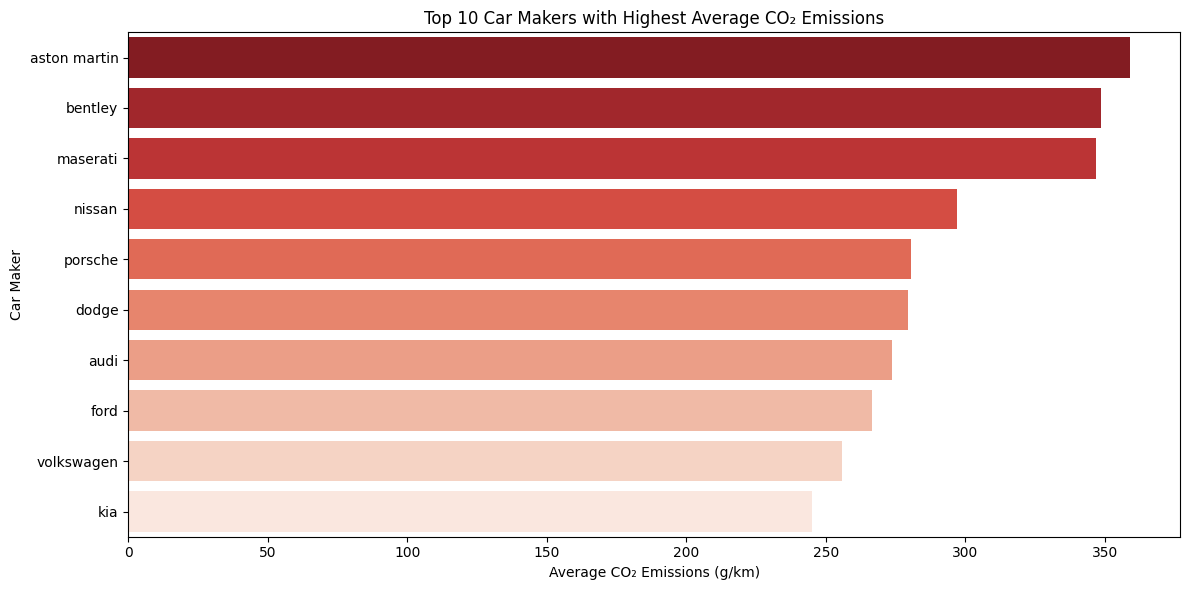

C:\Users\user\AppData\Local\Temp\ipykernel_24060\170502479.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Average_CO2_Emissions', y='Maker', data=top10_lowest, palette='Greens')


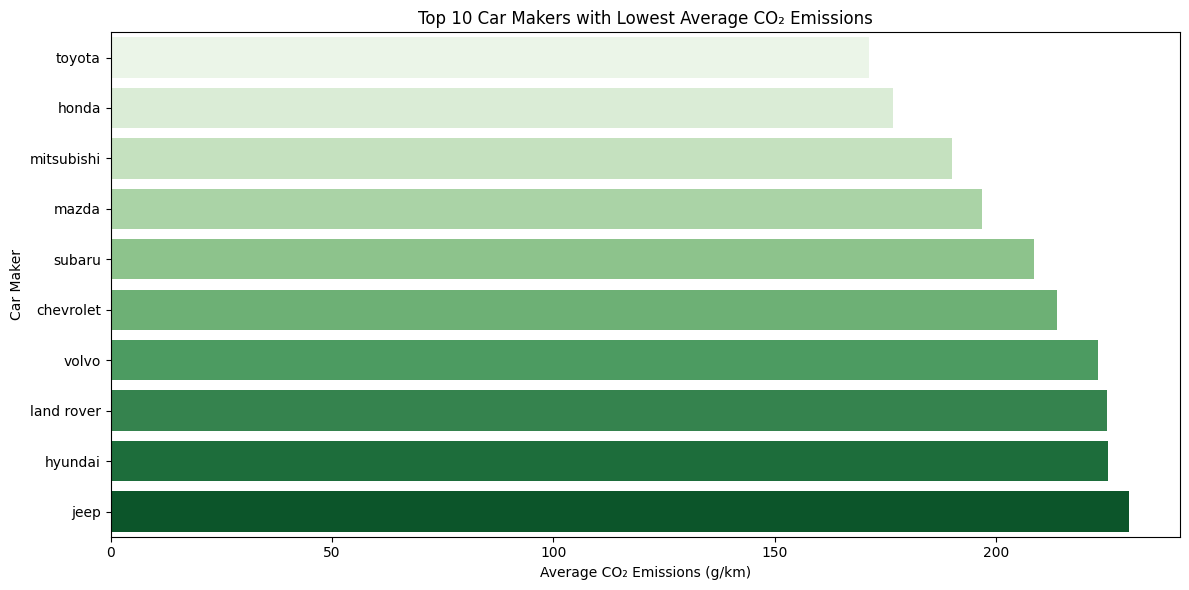

In [105]:
import matplotlib.pyplot as plt
import seaborn as sns

# visualisation by Maker
print("\n-------- visualization by Car Maker -------")

# Select top 10 car makers with highest average CO2 emissions
top10_highest = Maker_emissions_summary_sorted.head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x='Average_CO2_Emissions', y='Maker', data=top10_highest, palette='Reds_r')
plt.title('Top 10 Car Makers with Highest Average CO₂ Emissions')
plt.xlabel('Average CO₂ Emissions (g/km)')
plt.ylabel('Car Maker')
plt.tight_layout()
plt.show()

# Select bottom 10 car makers with lowest average CO2 emissions
top10_lowest = Maker_emissions_summary_sorted.tail(10).iloc[::-1]

plt.figure(figsize=(12, 6))
sns.barplot(x='Average_CO2_Emissions', y='Maker', data=top10_lowest, palette='Greens')
plt.title('Top 10 Car Makers with Lowest Average CO₂ Emissions')
plt.xlabel('Average CO₂ Emissions (g/km)')
plt.ylabel('Car Maker')
plt.tight_layout()
plt.show()




In [106]:
# Set multi-index for easier access of view to records by Maker and Model

matching_record_multi_index = matching_records.set_index(['Maker', 'Model'], inplace= False)
matching_record_multi_index

type  MODELYEAR    VEHICLECLASS    Fuel FuelType  \
Maker      Model                                                              
porsche    911 carrera  motokar     2014.0     MINICOMPACT  petrol   petrol   
           911 carrera  motokar     2014.0     MINICOMPACT  petrol   petrol   
honda      civic        motokar     2014.0         COMPACT  petrol   petrol   
           civic        motokar     2014.0         COMPACT  petrol   petrol   
           civic        motokar     2014.0         COMPACT  petrol   petrol   
...                         ...        ...             ...     ...      ...   
volkswagen tiguan           jip     2014.0     SUV - SMALL  petrol   petrol   
           tiguan           jip     2014.0     SUV - SMALL  petrol   petrol   
           tiguan           jip     2014.0     SUV - SMALL  petrol   petrol   
           tiguan           jip     2014.0     SUV - SMALL  petrol   petrol   
           touareg          jip     2014.0  SUV - STANDARD  petrol   petrol   

                        FuelConsumption_Combined  FuelConsumption_City  \
Maker      Model                                                         
porsche    911 carrera                      10.1                  11.6   
           911 carrera                      10.7                  12.5   
honda      civic                             7.0                   7.9   
           civic                             7.2                   8.1   
           civic                             7.6                   8.5   
...                                          ...                   ...   
volkswagen tiguan                           10.7                  11.7   
           tiguan                           11.6                  13.6   
           tiguan                           10.7                  11.7   
           tiguan                           11.6                  13.6   
           touareg                          12.2                  13.8   

                        FuelConsumption_Highway  FuelConsumption_Combined_MPG  \
Maker      Model                                                                
porsche    911 carrera                      8.3                          28.0   
           911 carrera                      8.6                          26.0   
honda      civic                            6.0                          40.0   
           civic                            6.2                          39.0   
           civic                            6.6                          37.0   
...                                         ...                           ...   
volkswagen tiguan                           9.5                          26.0   
           tiguan                           9.2                          24.0   
           tiguan                           9.5                          26.0   
           tiguan                           9.2                          24.0   
           touareg                         10.3                          23.0   

                        CO2EMISSIONS  
Maker      Model                      
porsche    911 carrera         232.0  
           911 carrera         246.0  
honda      civic               161.0  
           civic               166.0  
           civic               175.0  
...                              ...  
volkswagen tiguan              246.0  
           tiguan              267.0  
           tiguan              246.0  
           tiguan              267.0  
           touareg             281.0  

[8016 rows x 10 columns]